# Teste de hipótese T para média salárial

## Hipótese proposta:H0 o Salário de um engenheiro no Brasil é de RS 7.331,00

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
# amostra obtida via pesquisa

df = pd.read_excel('Salários Eng.xlsx')
df.head(10)

,Entrevistado,Salário Informado
0,x1,6800.00
1,x2,6800.00
2,x3,6800.01
3,x4,6800.02
4,x5,6800.03
5,x6,6800.04
6,x7,6800.05
7,x8,6800.06
8,x9,6800.07
9,x10,6800.08


In [13]:
print(df.shape)

(51, 2)


In [14]:
# Transformação dos dados
df['Salário Informado'] = pd.to_numeric(df['Salário Informado'])

In [15]:
df.dtypes

Entrevistado          object
Salário Informado    float64
dtype: object

# Verificando a distribuição dos dados

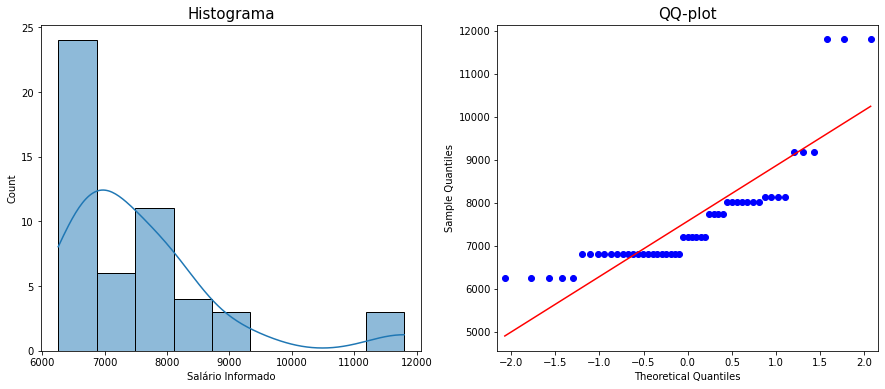

In [16]:
#histograma e qq plot
import statsmodels.api as sm

fig, ax = plt.subplots(1, 2, figsize=(15,6))

sns.histplot(df['Salário Informado'], kde=True, ax=ax[0])
ax[0].set_title('Histograma', fontsize=15)

sm.ProbPlot(df['Salário Informado']).qqplot(line='s', ax=ax[1])
ax[1].set_title('QQ-plot', fontsize=15)

plt.show()

## Aplicando o teste de normalidade Kolmogorov-Smirnov

In [20]:
from scipy.stats import kstest, norm

ks_statistic, p_value = kstest(df['Salário Informado'], 'norm')
print(ks_statistic, p_value)
if(p_value <= 0.05):
    print('Distribuição próxima ou igual a normal!')
else:
    print('Distribuição não normal')

1.0 0.0
Distribuição próxima ou igual a normal!


## Obtendo as estatísticas da amostra

In [21]:
salario_describe = df['Salário Informado'].describe().round(2).reset_index()
salario_describe.columns = ['Estatística', 'Salário']
salario_describe

,Estatística,Salário
0,count,51.00
1,mean,7573.35
2,std,1303.59
3,min,6254.10
4,25%,6800.06
5,50%,7200.21
6,75%,8011.18
7,max,11800.33


### Aplicando o teste de hipótese T-score

In [22]:
stat, p = stats.ttest_1samp(df['Salário Informado'], popmean=7331.00)

print('Estatística de teste: %.2f' %(stat.round(2)))
print('P-Valor: %.2f' %(p.round(2)))

print('\nResultado:')
if p > 0.05:
    print('A média salarial pode ser R$ 7.331,00')
else:
    print('A média salarial pode ser maior que R$ 7.331,00')

Estatística de teste: 1.33
P-Valor: 0.19

Resultado:
A média salarial pode ser R$ 7.331,00


### Neste caso considerando um grau de significancia alpha = 0,05

### A hipótese proposta não pode ser rejeitada

### Rejeita se p-Valor <= 0,01 (casos mais sérios)

### ou Rejeita se p-Valor <= 0,05

# Erro tipo I (alpha): O algoritmo rejeita a hipótese nula, mas ela é verdadeira

# Erro tipo II (beta): O algoritmo aceita a hipótese nula mas ela é falsa